# Análise Comparativa: Prim vs Kruskal
## Template de Jupyter Notebook para análise dos resultados

In [ ]:
# Imports e Configuração
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [ ]:
# Carregar Dados
# Carregar resultados dos experimentos (arquivo em results/ na raiz do projeto)
# O notebook está em src/, então usamos caminho relativo ../results/
df = pd.read_csv('../results/resultados_experimentos.csv')

# Visualizar primeiras linhas
print("Dados carregados:")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nColunas: {df.columns.tolist()}")

# Informações sobre os grafos
print("\nGrafos nos experimentos:")
print(df.groupby('graph_name').agg({
    'n_vertices': 'first',
    'n_edges': 'first',
    'repetition': 'count'
}))

Dados carregados:
  graph_name  n_vertices  n_edges algorithm  repetition  time_seconds  \
0     Grafo1        8980    12629      prim           1      0.030969   
1     Grafo1        8980    12629      prim           2      0.027754   
2     Grafo1        8980    12629      prim           3      0.025920   
3     Grafo1        8980    12629      prim           4      0.025402   
4     Grafo1        8980    12629      prim           5      0.025614   

   memory_mb  peak_memory_mb  cpu_seconds    mst_weight  mst_edges_count  \
0   0.527946        0.733574     0.031250  3.015372e+06             8979   
1   0.620163        0.825790     0.015625  3.015372e+06             8979   
2   0.498100        0.703728     0.031250  3.015372e+06             8979   
3   0.498100        0.703728     0.015625  3.015372e+06             8979   
4   0.498100        0.703728     0.031250  3.015372e+06             8979   

   valid                                     validation_msg  mem_rss_mb  \
0   True  M

In [ ]:
# Estatísticas Básicas
# Calcular médias por grafo e algoritmo
summary = df.groupby(['graph_name', 'algorithm']).agg({
    'time_seconds': ['mean', 'std', 'min', 'max'],
    'peak_memory_mb': ['mean', 'std', 'min', 'max'],
    'mst_weight': 'first',
    'mst_edges_count': 'first',
    'valid': 'all'
}).round(4)

print("Resumo estatístico:")
print(summary)

Resumo estatístico:
                     time_seconds                         peak_memory_mb  \
                             mean     std     min     max           mean   
graph_name algorithm                                                       
Grafo1     kruskal         0.0237  0.0008  0.0233  0.0258         0.7316   
           prim            0.0263  0.0018  0.0253  0.0310         0.7189   
Grafo2     kruskal         0.0127  0.0002  0.0125  0.0130         0.3651   
           prim            0.0132  0.0005  0.0128  0.0147         0.3624   
Grafo3     kruskal         0.1095  0.0011  0.1076  0.1107         3.4268   
           prim            0.1238  0.0050  0.1170  0.1350         3.3431   
Grafo4     kruskal         0.0342  0.0022  0.0332  0.0404         1.0539   
           prim            0.0334  0.0002  0.0331  0.0338         1.0190   
Grafo5     kruskal         0.7332  0.0083  0.7220  0.7505        20.1652   
           prim            0.8611  0.0220  0.8461  0.9192        19.

In [ ]:
# Validação dos Resultados
# verificar se ambos algoritmos produziram MSTs com mesmo peso
comparison = df.groupby(['graph_name', 'algorithm'])['mst_weight'].first().unstack()
comparison['diferenca'] = abs(comparison['prim'] - comparison['kruskal'])

print("\nComparação de pesos das MSTs:")
print(comparison)

# Verificar validade
print("\nTodas as MSTs válidas?")
print(df.groupby(['graph_name', 'algorithm'])['valid'].all())


Comparação de pesos das MSTs:
algorithm        kruskal          prim     diferenca
graph_name                                          
Grafo1      3.015372e+06  3.015372e+06  6.053597e-09
Grafo2      2.641212e+06  2.641212e+06  1.862645e-09
Grafo3      3.061890e+06  3.061890e+06  6.053597e-09
Grafo4      4.794641e+06  4.794641e+06  2.793968e-09
Grafo5      1.639132e+07  1.639132e+07  3.818423e-07
Grafo6      1.234251e+07  1.234251e+07  1.005828e-07

Todas as MSTs válidas?
graph_name  algorithm
Grafo1      kruskal      True
            prim         True
Grafo2      kruskal      True
            prim         True
Grafo3      kruskal      True
            prim         True
Grafo4      kruskal      True
            prim         True
Grafo5      kruskal      True
            prim         True
Grafo6      kruskal      True
            prim         True
Name: valid, dtype: bool


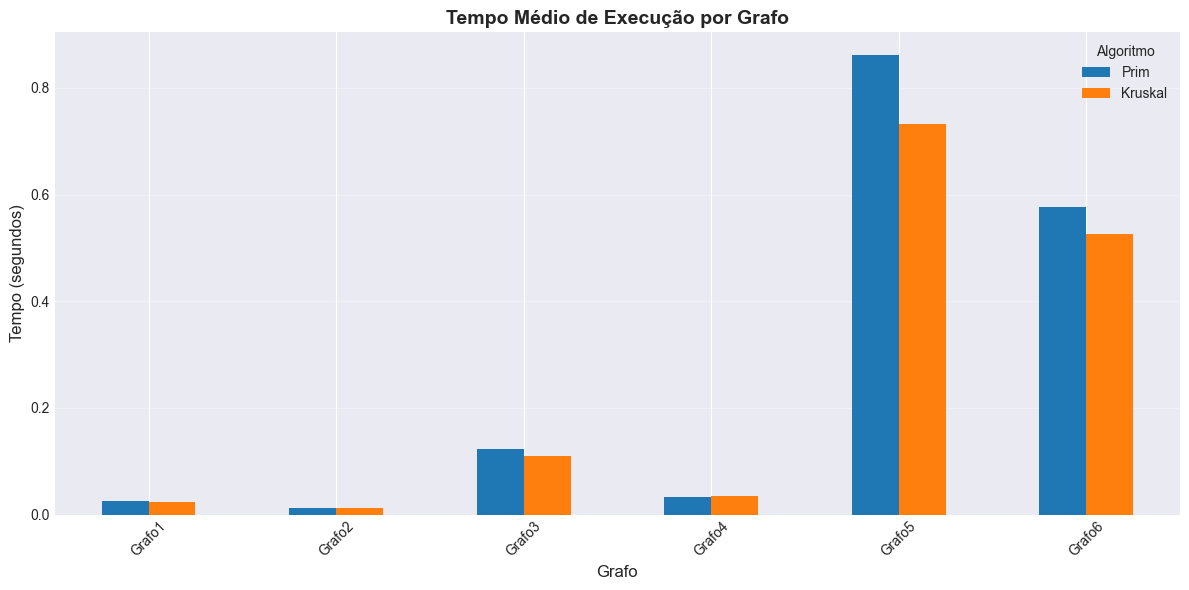

In [ ]:
# Gráfico - Tempo de Execução
fig, ax = plt.subplots(figsize=(12, 6))

# Calcular médias
avg_time = df.groupby(['graph_name', 'algorithm'])['time_seconds'].mean().unstack()

# Reordenar colunas: prim primeiro, kruskal depois
avg_time = avg_time[['prim', 'kruskal']]

# Gráfico de barras
avg_time.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_title('Tempo Médio de Execução por Grafo', fontsize=14, fontweight='bold')
ax.set_xlabel('Grafo', fontsize=12)
ax.set_ylabel('Tempo (segundos)', fontsize=12)
ax.legend(['Prim', 'Kruskal'], title='Algoritmo')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

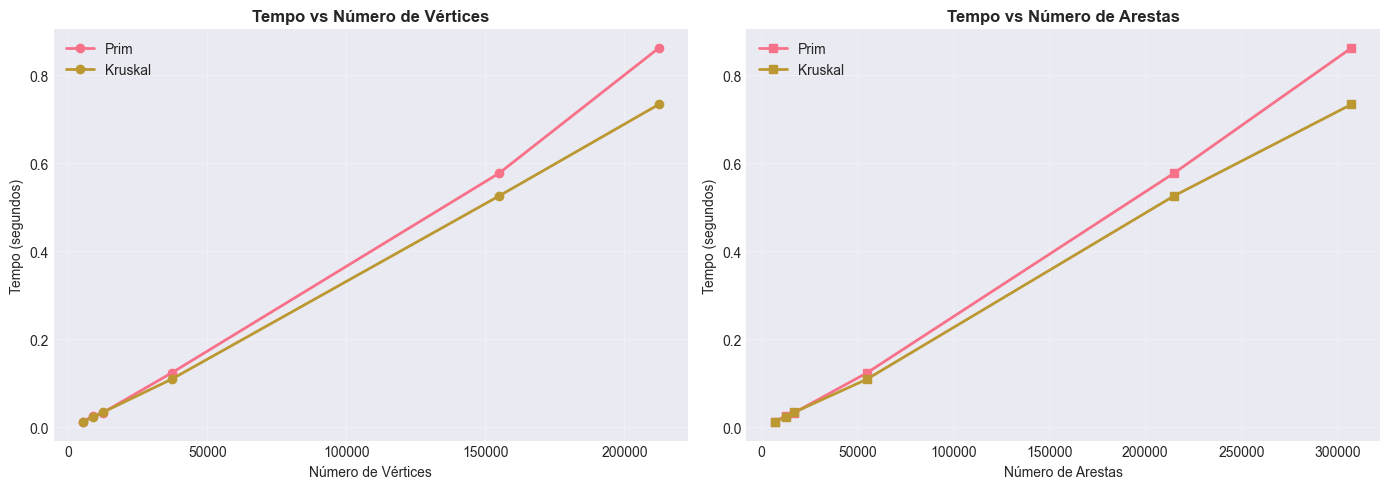

In [ ]:
# Gráfico - Tempo vs Tamanho do Grafo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Por número de vértices
for algo in ['prim', 'kruskal']:
    data = df[df['algorithm'] == algo].groupby('n_vertices')['time_seconds'].mean()
    ax1.plot(data.index, data.values, marker='o', label=algo.capitalize(), linewidth=2)

ax1.set_title('Tempo vs Número de Vértices', fontsize=12, fontweight='bold')
ax1.set_xlabel('Número de Vértices')
ax1.set_ylabel('Tempo (segundos)')
ax1.legend()
ax1.grid(alpha=0.3)

# Por número de arestas
for algo in ['prim', 'kruskal']:
    data = df[df['algorithm'] == algo].groupby('n_edges')['time_seconds'].mean()
    ax2.plot(data.index, data.values, marker='s', label=algo.capitalize(), linewidth=2)

ax2.set_title('Tempo vs Número de Arestas', fontsize=12, fontweight='bold')
ax2.set_xlabel('Número de Arestas')
ax2.set_ylabel('Tempo (segundos)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

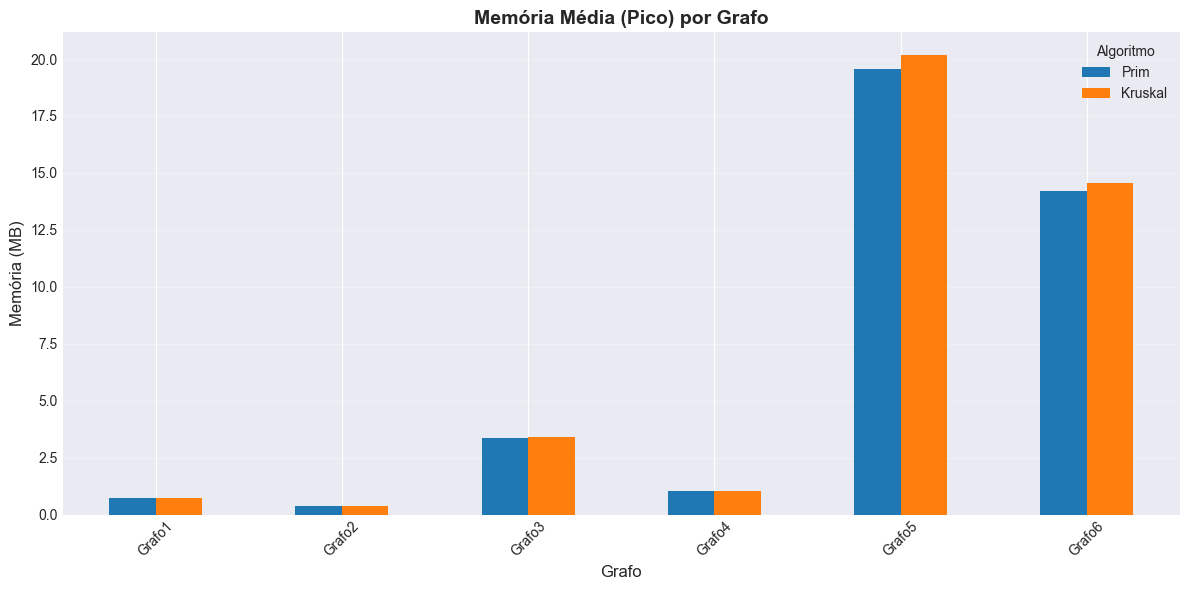

In [ ]:
# Gráfico - Memória
fig, ax = plt.subplots(figsize=(12, 6))

avg_memory = df.groupby(['graph_name', 'algorithm'])['peak_memory_mb'].mean().unstack()

# Reordenar colunas: prim primeiro, kruskal depois
avg_memory = avg_memory[['prim', 'kruskal']]

avg_memory.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_title('Memória Média (Pico) por Grafo', fontsize=14, fontweight='bold')
ax.set_xlabel('Grafo', fontsize=12)
ax.set_ylabel('Memória (MB)', fontsize=12)
ax.legend(['Prim', 'Kruskal'], title='Algoritmo')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

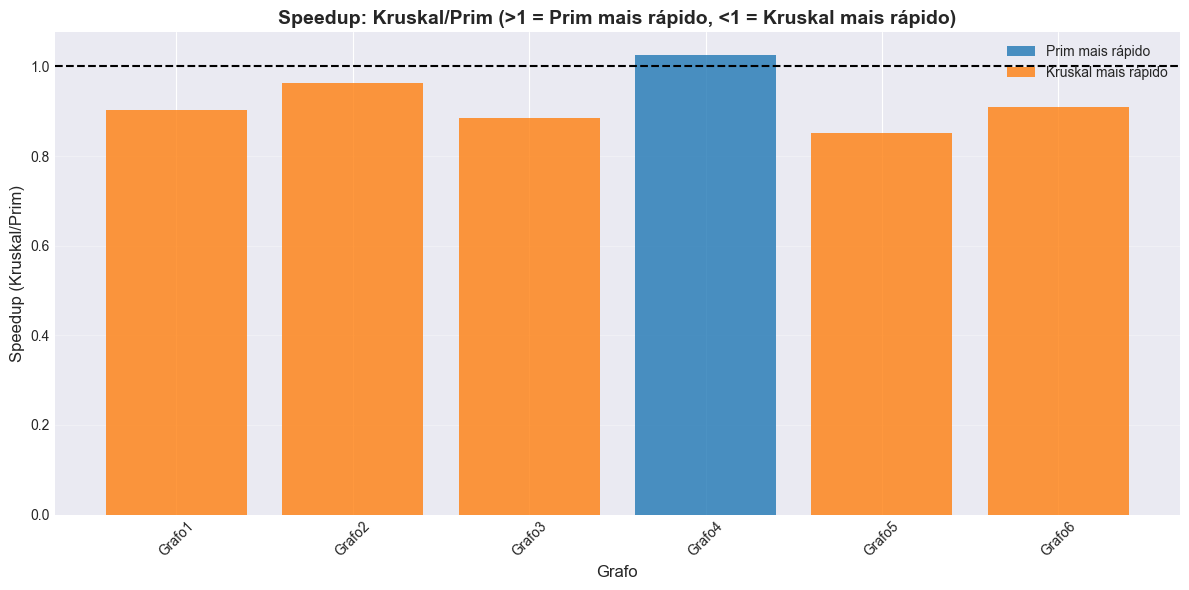


Speedup por grafo:
 graph  speedup mais_rapido
Grafo1 0.903745     Kruskal
Grafo2 0.962819     Kruskal
Grafo3 0.884763     Kruskal
Grafo4 1.024828        Prim
Grafo5 0.851454     Kruskal
Grafo6 0.910542     Kruskal


In [ ]:
# Speedup
# calcular speedup (quanto um é mais rápido que o outro)
speedup_data = []

for graph in df['graph_name'].unique():
    prim_time = df[(df['graph_name'] == graph) & 
                   (df['algorithm'] == 'prim')]['time_seconds'].mean()
    kruskal_time = df[(df['graph_name'] == graph) & 
                      (df['algorithm'] == 'kruskal')]['time_seconds'].mean()
    
    speedup = kruskal_time / prim_time
    speedup_data.append({
        'graph': graph,
        'speedup': speedup,
        'mais_rapido': 'Prim' if speedup > 1 else 'Kruskal'
    })

speedup_df = pd.DataFrame(speedup_data)

fig, ax = plt.subplots(figsize=(12, 6))

# Cores: azul para Prim mais rápido, laranja para Kruskal mais rápido
colors = ['#1f77b4' if s > 1 else '#ff7f0e' for s in speedup_df['speedup']]

bars = ax.bar(speedup_df['graph'], speedup_df['speedup'], color=colors, alpha=0.8)
ax.axhline(y=1, color='black', linestyle='--', linewidth=1.5)

# Legenda customizada
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1f77b4', alpha=0.8, label='Prim mais rápido'),
    Patch(facecolor='#ff7f0e', alpha=0.8, label='Kruskal mais rápido')
]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_title('Speedup: Kruskal/Prim (>1 = Prim mais rápido, <1 = Kruskal mais rápido)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Grafo', fontsize=12)
ax.set_ylabel('Speedup (Kruskal/Prim)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nSpeedup por grafo:")
print(speedup_df.to_string(index=False))

In [ ]:
# Conclusões
print("="*70)
print("CONCLUSÕES")
print("="*70)

# Algoritmo mais rápido em média
prim_avg = df[df['algorithm'] == 'prim']['time_seconds'].mean()
kruskal_avg = df[df['algorithm'] == 'kruskal']['time_seconds'].mean()

print(f"\nTempo médio geral:")
print(f"  Prim:    {prim_avg:.4f}s")
print(f"  Kruskal: {kruskal_avg:.4f}s")

if prim_avg < kruskal_avg:
    print(f"\n→ Prim foi {kruskal_avg/prim_avg:.2f}x mais rápido em média")
else:
    print(f"\n→ Kruskal foi {prim_avg/kruskal_avg:.2f}x mais rápido em média")

# Memória
prim_mem = df[df['algorithm'] == 'prim']['peak_memory_mb'].mean()
kruskal_mem = df[df['algorithm'] == 'kruskal']['peak_memory_mb'].mean()

print(f"\nMemória média (pico):")
print(f"  Prim:    {prim_mem:.2f} MB")
print(f"  Kruskal: {kruskal_mem:.2f} MB")

# Consistência
print(f"\nConsistência dos resultados:")
print(f"  Todas MSTs válidas: {df['valid'].all()}")
print(f"  Pesos idênticos: {(comparison['diferenca'] < 0.01).all()}")

# Análise por tamanho
print(f"\nAnálise por tamanho do grafo:")
for _, row in speedup_df.iterrows():
    n_v = df[df['graph_name'] == row['graph']]['n_vertices'].iloc[0]
    print(f"  {row['graph']} ({n_v:,} vértices): {row['mais_rapido']} mais rápido ({row['speedup']:.2f}x)")

print("\n" + "="*70)

CONCLUSÕES

Tempo médio geral:
  Prim:    0.2725s
  Kruskal: 0.2398s

→ Kruskal foi 1.14x mais rápido em média

Memória média (pico):
  Prim:    6.53 MB
  Kruskal: 6.72 MB

Consistência dos resultados:
  Todas MSTs válidas: True
  Pesos idênticos: True

Análise por tamanho do grafo:
  Grafo1 (8,980 vértices): Kruskal mais rápido (0.90x)
  Grafo2 (5,152 vértices): Kruskal mais rápido (0.96x)
  Grafo3 (37,128 vértices): Kruskal mais rápido (0.88x)
  Grafo4 (12,368 vértices): Prim mais rápido (1.02x)
  Grafo5 (212,341 vértices): Kruskal mais rápido (0.85x)
  Grafo6 (154,938 vértices): Kruskal mais rápido (0.91x)

